In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [14]:
df = pd.read_csv("stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [18]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [27]:
print("Categorical in 'gender' variable: ", end=" ")
print(df['gender'].unique())

print("Categorical in 'race/ethnicity' variable: ", end=" ")
print(df['race_ethnicity'].unique())

print("Categorical in 'parental level of education' variable: ", end=" ")
print(df['parental_level_of_education'].unique())

print("Categorical in 'lunch' variable: ", end=" ")
print(df['lunch'].unique())

print("Categorical in 'test preparation course' variable: ", end=" ")
print(df['test_preparation_course'].unique())

Categorical in 'gender' variable:  ['female' 'male']
Categorical in 'race/ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categorical in 'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categorical in 'lunch' variable:  ['standard' 'free/reduced']
Categorical in 'test preparation course' variable:  ['none' 'completed']


In [29]:
## Define the numeric and categorical columns
numerical_columns = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_columns = [feature for feature in df.columns if df[feature].dtype == 'O']

## Print columns
print("We have {} numerical columns: {}".format(len(numerical_columns), numerical_columns))
print("We have {} categorical columns: {}".format(len(categorical_columns), categorical_columns))

We have 3 numerical columns: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical columns: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [30]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [32]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [35]:
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
math_full = df[df['math_score'] == 100]['average_score'].count()

print(f"Number of studens with full marks in reading: {reading_full}")
print(f"Number of studens with full marks in writing: {writing_full}")
print(f"Number of studens with full marks in math: {math_full}")

Number of studens with full marks in reading: 17
Number of studens with full marks in writing: 14
Number of studens with full marks in math: 7


In [37]:
reading_less_20 = df[df['reading_score'] < 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] < 20]['average_score'].count()
math_less_20 = df[df['math_score'] < 20]['average_score'].count()

## Print
print(f"Number of students with less than 20 marks in reading: {reading_less_20}")
print(f"Number of students with less than 20 marks in writing: {writing_less_20}")
print(f"Number of students with less than 20 marks in math: {math_less_20}")

Number of students with less than 20 marks in reading: 1
Number of students with less than 20 marks in writing: 3
Number of students with less than 20 marks in math: 4


<Axes: xlabel='average_score', ylabel='Count'>

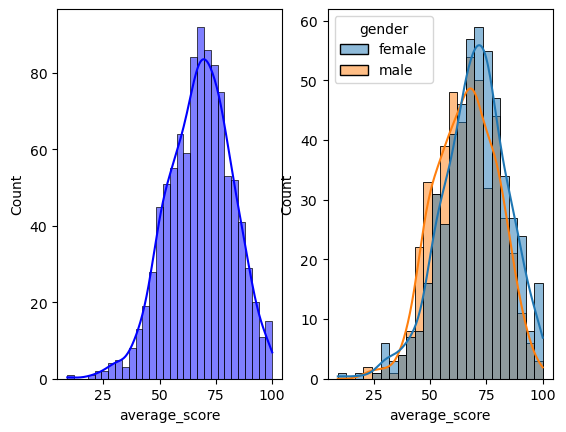

In [39]:
## Histograms & KDE plots
plt.subplot(121)
sns.histplot(data=df, x='average_score', kde=True, bins=30, color='blue')
plt.subplot(122)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')

<Axes: xlabel='total_score', ylabel='Count'>

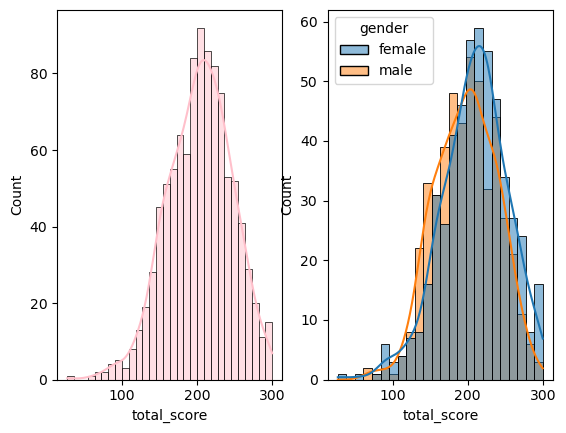

In [43]:
plt.subplot(121)
sns.histplot(data=df, x='total_score', kde=True, bins=30, color='pink')
plt.subplot(122)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')